In [1]:
# 📦 Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [2]:
iris = load_iris()
X = iris.data

df = pd.DataFrame(X, columns=iris.feature_names)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


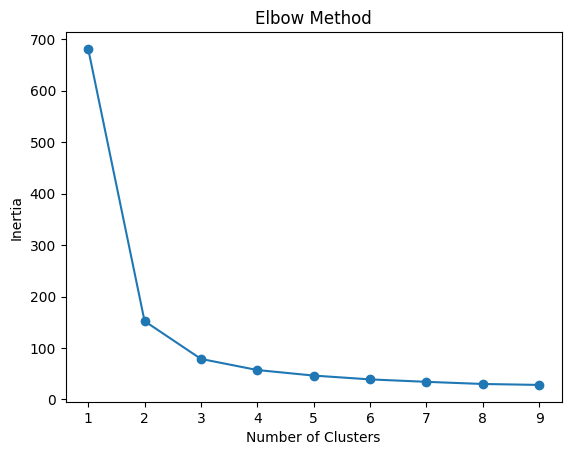

In [3]:
inertia = []

for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 10), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

In [4]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X)

df['cluster'] = clusters
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),cluster
0,5.1,3.5,1.4,0.2,1
1,4.9,3.0,1.4,0.2,1
2,4.7,3.2,1.3,0.2,1
3,4.6,3.1,1.5,0.2,1
4,5.0,3.6,1.4,0.2,1


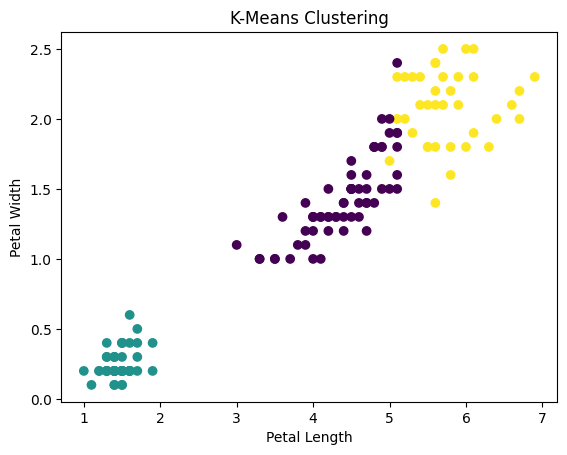

In [5]:
plt.scatter(df['petal length (cm)'], df['petal width (cm)'], c=df['cluster'])
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("K-Means Clustering")
plt.show()

In [6]:
score = silhouette_score(X, clusters)
print("Silhouette Score:", score)

Silhouette Score: 0.5528190123564095


## 📊 Observations

- The Elbow Method shows a clear bend at k = 3, indicating the optimal number of clusters.
- K-Means successfully grouped the data into three distinct clusters.
- The scatter plot (petal length vs petal width) shows clear separation between clusters.
- One cluster is completely distinct, while the other two are slightly closer but still separable.
- The silhouette score (~0.55) indicates moderate to good clustering quality.

## 🧠 Insight

- K-Means clustering effectively identifies natural groupings in the Iris dataset without using labels.
- The presence of three well-defined clusters aligns with the dataset’s actual class structure.
- Feature selection (petal length and width) plays a key role in revealing clear cluster boundaries.
- Unlike supervised learning, clustering provides insight into the underlying structure of data without prior knowledge of class labels.